In [1]:
# %% ======================================================
# 1. Imports + config
# ==========================================================
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm
import scipy.integrate as si

from sksurv.util import Surv
from torchvision.models import resnet18, resnet34, resnet50
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc

import torch
import torch.nn as nn

# Compatibility patch for older lifelines with newer SciPy
if not hasattr(si, "trapz"):
    from scipy.integrate import trapezoid
    si.trapz = trapezoid

if not hasattr(si, "cumtrapz"):
    from scipy.integrate import cumulative_trapezoid
    si.cumtrapz = cumulative_trapezoid

if not hasattr(si, "simps"):
    from scipy.integrate import simpson
    si.simps = simpson

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# image loading
from PIL import Image
import tifffile

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ALL_DATA_CSV = Path("/proj/berzelius-2025-315/users/x_dilwi/bomi2_image_level_with_survival.csv")
FOLDS_DIR = Path("/proj/berzelius-2025-315/users/x_dilwi/BOMI2_folds")

# Folder containing the saved arrays, assumed as <image_stem>.npy
IMAGE_ROOT = Path("/proj/berzelius-2025-315/users/x_dilwi/AI-supported-Survival-Prediction-from-Multichannel-Microscopy-Images-of-Cancer-Tissue/Reviewing_copy_rerun/Baseline_new/arrays_aspect128_log_dropch5")

RUN_NAME = "ResNet18_Baseline"

DAYS_PER_YEAR = 365.25
AUC_TIMES = np.array([1, 2, 3, 4, 5], dtype=float) * DAYS_PER_YEAR
SURV_TIMES = np.array([3, 5], dtype=float) * DAYS_PER_YEAR
PLOT_TIME_GRID = np.linspace(0, 5 * DAYS_PER_YEAR, 100)

# CNN settings

CNN_MAX_EPOCHS = 30
CNN_LR = 1e-5
CNN_WEIGHT_DECAY = 1e-6
CNN_EMBED_DIM = 256

# simple augmentations
AUG_HFLIP_P = 0.5
AUG_VFLIP_P = 0.5
AUG_MAX_SHIFT = 0       # pixels

# Optional: set real names if you want
CHANNEL_NAMES = None
# Example if needed after dropch5:
CHANNEL_NAMES = ["DAPI", "CD4", "CD20", "CD8", "FoxP3", "PanCK", "Autofluorescence"]

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("DEVICE:", DEVICE)
print("RUN:", RUN_NAME)
print("CSV exists:", ALL_DATA_CSV.exists())
print("Folds dir exists:", FOLDS_DIR.exists())
print("IMAGE_ROOT exists:", IMAGE_ROOT.exists())


# %% ======================================================
# 2. Helper functions
# ==========================================================
def decode_name(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)

def norm_name(x):
    s = decode_name(x).strip()
    s = Path(s).name
    s = re.sub(r"\.tiff?$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"_core$", "", s, flags=re.IGNORECASE)
    return s

def channel_label(i):
    if CHANNEL_NAMES is not None and len(CHANNEL_NAMES) > i:
        return CHANNEL_NAMES[i]
    return f"ch_{i}"

def get_split_patient_ids(split_df, all_df):
    # direct patient_id
    for col in ["patient_id", "patient", "PatientID", "patientID", "pid", "ID"]:
        if col in split_df.columns:
            return np.sort(pd.to_numeric(split_df[col], errors="coerce").dropna().astype(int).unique())

    # map through image names
    for col in ["image_name", "image_stem", "name", "filename", "file_name", "core_name"]:
        if col in split_df.columns:
            tmp = split_df[[col]].copy()
            tmp["image_stem"] = tmp[col].astype(str).map(norm_name)
            tmp = tmp.merge(
                all_df[["image_stem", "patient_id"]].drop_duplicates(),
                on="image_stem",
                how="left"
            )
            return np.sort(tmp["patient_id"].dropna().astype(int).unique())

    raise ValueError(f"Could not find patient_id or image-name column in split file. Columns: {split_df.columns.tolist()}")

def c_index(df_pat, risk):
    return concordance_index_censored(
        df_pat["event"].astype(bool).values,
        df_pat["time"].astype(float).values,
        np.asarray(risk, dtype=float)
    )[0]

def get_common_auc_times_by_split(fold_data, candidate_times):
    """
    Find AUC times that are valid for ALL folds for each split.
    This makes mean_auc directly comparable across folds.
    """
    out = {}
    for split in ["train", "val", "test"]:
        valid_times = []
        for t in candidate_times:
            ok = True
            for fold in sorted(fold_data.keys()):
                df_train = fold_data[fold]["train"]["df"]
                df_eval = fold_data[fold][split]["df"]

                if len(df_train) == 0 or len(df_eval) == 0:
                    ok = False
                    break

                tmax = min(float(df_train["time"].max()), float(df_eval["time"].max()))
                if not (t > 0 and t < tmax):
                    ok = False
                    break
            if ok:
                valid_times.append(t)
        out[split] = np.array(valid_times, dtype=float)
    return out

def breslow_baseline(times, events, risk_scores):
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=bool)
    risk_scores = np.asarray(risk_scores, dtype=float)

    uniq = np.sort(np.unique(times[events]))
    if len(uniq) == 0:
        return np.array([]), np.array([])

    exp_risk = np.exp(risk_scores)
    H = 0.0
    cumhaz = []

    for t in uniq:
        d = np.sum((times == t) & events)
        risk_set = exp_risk[times >= t].sum()
        if risk_set > 0:
            H += d / risk_set
        cumhaz.append(H)

    return uniq, np.array(cumhaz, dtype=float)

def predict_survival(baseline_times, baseline_cumhaz, risk_scores, eval_times):
    if len(baseline_times) == 0:
        return np.ones((len(risk_scores), len(eval_times)))

    H0 = np.interp(
        eval_times,
        baseline_times,
        baseline_cumhaz,
        left=0.0,
        right=baseline_cumhaz[-1]
    )
    surv = np.exp(-np.exp(risk_scores)[:, None] * H0[None, :])
    return surv

def km_curve(times, events, time_grid):
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=bool)

    event_times = np.sort(np.unique(times[events]))
    surv = 1.0
    out = []
    i = 0

    for t in time_grid:
        while i < len(event_times) and event_times[i] <= t:
            tt = event_times[i]
            d = np.sum((times == tt) & events)
            n = np.sum(times >= tt)
            if n > 0:
                surv *= (1.0 - d / n)
            i += 1
        out.append(surv)

    return np.array(out)

def make_surv(df_pat):
    return Surv.from_arrays(
        event=df_pat["event"].astype(bool).values,
        time=df_pat["time"].astype(float).values
    )

def summarize_metrics(metrics_df):
    return (
        metrics_df.groupby("split", as_index=False)
        .agg(
            n_folds=("fold", "nunique"),
            c_index_mean=("c_index", "mean"),
            c_index_std=("c_index", "std"),
            mean_auc_mean=("mean_auc", "mean"),
            mean_auc_std=("mean_auc", "std"),
            risk_mean=("risk_mean", "mean"),
            risk_std=("risk_std", "mean"),
            s3_mean=("s3_mean", "mean"),
            s3_std=("s3_std", "mean"),
            s5_mean=("s5_mean", "mean"),
            s5_std=("s5_std", "mean"),
        )
    )

def plot_auc_curves(auc_df, title):
    plt.figure(figsize=(8, 5))
    for split in ["train", "val", "test"]:
        sub = auc_df[auc_df["split"] == split]
        if len(sub) == 0:
            continue
        agg = sub.groupby("time_years", as_index=False).agg(
            auc_mean=("auc", "mean"),
            auc_std=("auc", "std")
        )
        plt.plot(agg["time_years"], agg["auc_mean"], marker="o", label=split)
        plt.fill_between(
            agg["time_years"],
            agg["auc_mean"] - agg["auc_std"].fillna(0),
            agg["auc_mean"] + agg["auc_std"].fillna(0),
            alpha=0.2
        )
    plt.title(title)
    plt.xlabel("Time (years)")
    plt.ylabel("Time-dependent AUC")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_survival_curves(curve_df, split, title):
    sub = curve_df[curve_df["split"] == split].copy()
    if len(sub) == 0:
        return

    agg = sub.groupby("time_years", as_index=False).agg(
        actual_mean=("actual_survival", "mean"),
        actual_std=("actual_survival", "std"),
        pred_mean=("pred_survival", "mean"),
        pred_std=("pred_survival", "std"),
    )

    plt.figure(figsize=(8, 5))
    plt.plot(agg["time_years"], agg["actual_mean"], color="blue", label="Actual")
    plt.fill_between(
        agg["time_years"],
        agg["actual_mean"] - agg["actual_std"].fillna(0),
        agg["actual_mean"] + agg["actual_std"].fillna(0),
        color="blue", alpha=0.15
    )
    plt.plot(agg["time_years"], agg["pred_mean"], color="orange", label="Predicted")
    plt.fill_between(
        agg["time_years"],
        agg["pred_mean"] - agg["pred_std"].fillna(0),
        agg["pred_mean"] + agg["pred_std"].fillna(0),
        color="orange", alpha=0.15
    )
    plt.axvline(3, linestyle="--", color="gray")
    plt.axvline(5, linestyle="--", color="gray")
    plt.title(title)
    plt.xlabel("Time (years)")
    plt.ylabel("Survival probability")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_surv_history(history_df, title_prefix):
    if len(history_df) == 0:
        return

    agg = history_df.groupby("epoch", as_index=False).agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        val_loss_mean=("val_loss", "mean"),
        val_loss_std=("val_loss", "std"),
        val_c_index_mean=("val_c_index", "mean"),
        val_c_index_std=("val_c_index", "std"),
        lr_mean=("lr", "mean"),
    )

    plt.figure(figsize=(8, 5))
    plt.plot(agg["epoch"], agg["train_loss_mean"], label="Train Cox loss")
    plt.fill_between(
        agg["epoch"],
        agg["train_loss_mean"] - agg["train_loss_std"].fillna(0),
        agg["train_loss_mean"] + agg["train_loss_std"].fillna(0),
        alpha=0.2
    )
    plt.plot(agg["epoch"], agg["val_loss_mean"], label="Val Cox loss")
    plt.fill_between(
        agg["epoch"],
        agg["val_loss_mean"] - agg["val_loss_std"].fillna(0),
        agg["val_loss_mean"] + agg["val_loss_std"].fillna(0),
        alpha=0.2
    )
    plt.title(f"{title_prefix} - Cox loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(agg["epoch"], agg["val_c_index_mean"], label="Val C-index")
    plt.fill_between(
        agg["epoch"],
        agg["val_c_index_mean"] - agg["val_c_index_std"].fillna(0),
        agg["val_c_index_mean"] + agg["val_c_index_std"].fillna(0),
        alpha=0.2
    )
    plt.title(f"{title_prefix} - Validation C-index")
    plt.xlabel("Epoch")
    plt.ylabel("C-index")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(agg["epoch"], agg["lr_mean"], label="Learning rate")
    plt.yscale("log")
    plt.title(f"{title_prefix} - Learning rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.legend()
    plt.tight_layout()
    plt.show()




# %% ======================================================
# 3. Load full CSV
# ==========================================================
all_df = pd.read_csv(ALL_DATA_CSV)
all_df["patient_id"] = pd.to_numeric(all_df["patient_id"], errors="coerce")
all_df["time"] = pd.to_numeric(all_df["time"], errors="coerce")
all_df["event"] = pd.to_numeric(all_df["event"], errors="coerce")
all_df["image_name"] = all_df["image_name"].astype(str).str.strip()
all_df["image_stem"] = all_df["image_name"].map(norm_name)

print("all_df shape:", all_df.shape)
print("Unique patient IDs in full CSV:", all_df["patient_id"].dropna().astype(int).nunique())
display(all_df.head())


# %% ======================================================
# 4. Read train / val / test folds and remove patients with time <= 0
# ==========================================================
patient_time_df = (
    all_df[["patient_id", "time", "event"]]
    .dropna()
    .copy()
)
patient_time_df["patient_id"] = patient_time_df["patient_id"].astype(int)
patient_time_df = patient_time_df.drop_duplicates(subset=["patient_id"]).copy()

valid_patient_ids = set(patient_time_df.loc[patient_time_df["time"] > 0, "patient_id"].tolist())
removed_patient_ids = set(patient_time_df.loc[patient_time_df["time"] <= 0, "patient_id"].tolist())

print("Patients with time > 0 :", len(valid_patient_ids))
print("Patients removed (time <= 0):", len(removed_patient_ids))

folds = {}
fold_rows = []

for fold in range(10):
    folds[fold] = {}

    for split in ["train", "val", "test"]:
        fp = FOLDS_DIR / f"split_{fold}_{split}.csv"
        df_split = pd.read_csv(fp)
        patient_ids = get_split_patient_ids(df_split, all_df)
        patient_ids = np.array(sorted(set(patient_ids).intersection(valid_patient_ids)), dtype=int)

        folds[fold][split] = {
            "file": fp,
            "df": df_split,
            "patient_ids": patient_ids,
        }

        fold_rows.append({
            "fold": fold,
            "split": split,
            "file": fp.name,
            "n_rows": len(df_split),
            "n_unique_patients_after_time_filter": len(patient_ids),
        })

fold_summary_df = pd.DataFrame(fold_rows).sort_values(["fold", "split"]).reset_index(drop=True)
display(fold_summary_df)


# %% ======================================================
# 5. Compare patient IDs in full CSV vs fold CSVs
# ==========================================================
all_patients_full = set(all_df["patient_id"].dropna().astype(int).unique())
all_patients_folds = set()

for fold in range(10):
    for split in ["train", "val", "test"]:
        all_patients_folds |= set(folds[fold][split]["patient_ids"])

print("Unique patient IDs in full CSV :", len(all_patients_full))
print("Unique patient IDs in fold CSVs:", len(all_patients_folds))
print("Patients in full CSV but not in fold CSVs:", len(all_patients_full - all_patients_folds))
print("Patients in fold CSVs but not in full CSV:", len(all_patients_folds - all_patients_full))


# %% ======================================================
# 6. CNN image helpers
# ==========================================================
def resolve_image_path_from_stem(stem):
    return IMAGE_ROOT / f"{stem}.npy"

def read_image_any(path):
    path = Path(path)
    ext = path.suffix.lower()

    if ext == ".npy":
        arr = np.load(path)
    elif ext in [".tif", ".tiff"]:
        arr = tifffile.imread(path)
    else:
        arr = np.array(Image.open(path))

    arr = np.asarray(arr)

    # Convert to CHW
    if arr.ndim == 2:
        arr = arr[None, :, :]
    elif arr.ndim == 3:
        if arr.shape[0] not in [1, 3, 4, 5, 6, 7, 8] and arr.shape[-1] in [1, 3, 4, 5, 6, 7, 8]:
            arr = np.moveaxis(arr, -1, 0)
    else:
        raise ValueError(f"Unsupported image shape {arr.shape} for {path}")

    return arr.astype(np.float32)

def compute_channel_stats(df, max_samples=2000):
    if len(df) == 0:
        raise ValueError("compute_channel_stats got an empty dataframe.")

    idxs = np.arange(len(df))
    if len(df) > max_samples:
        rng = np.random.default_rng(SEED)
        idxs = rng.choice(idxs, size=max_samples, replace=False)

    sum_c = None
    sumsq_c = None
    n_pix = 0

    for i in tqdm(idxs, desc="Computing channel stats"):
        arr = read_image_any(df.iloc[i]["image_path"])
        c, h, w = arr.shape
        flat = arr.reshape(c, -1)

        if sum_c is None:
            sum_c = flat.sum(axis=1)
            sumsq_c = (flat ** 2).sum(axis=1)
        else:
            sum_c += flat.sum(axis=1)
            sumsq_c += (flat ** 2).sum(axis=1)

        n_pix += flat.shape[1]

    if sum_c is None or n_pix == 0:
        raise ValueError("No valid images were processed in compute_channel_stats.")

    mean = sum_c / n_pix
    var = np.maximum(sumsq_c / n_pix - mean ** 2, 1e-12)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)

def augment_batch(x, hflip_p=0.5, vflip_p=0.5, max_shift=4, noise_std=0.01):
    """
    Simple training-time augmentations for normalized tensors.
    x: (N, C, H, W)
    """
    x = x.clone()

    # per-sample horizontal flip
    if hflip_p > 0:
        hmask = torch.rand(x.size(0), device=x.device) < hflip_p
        if hmask.any():
            x[hmask] = torch.flip(x[hmask], dims=[-1])

    # per-sample vertical flip
    if vflip_p > 0:
        vmask = torch.rand(x.size(0), device=x.device) < vflip_p
        if vmask.any():
            x[vmask] = torch.flip(x[vmask], dims=[-2])

    # small random translations (per sample) using torch.roll
    if max_shift > 0:
        shifts_y = torch.randint(-max_shift, max_shift + 1, (x.size(0),), device=x.device)
        shifts_x = torch.randint(-max_shift, max_shift + 1, (x.size(0),), device=x.device)

        x_aug = []
        for i in range(x.size(0)):
            xi = torch.roll(x[i], shifts=(int(shifts_y[i].item()), int(shifts_x[i].item())), dims=(-2, -1))
            x_aug.append(xi)
        x = torch.stack(x_aug, dim=0)

    # very mild Gaussian noise
    if noise_std > 0:
        x = x + noise_std * torch.randn_like(x)

    return x

def prepare_split_tensors(df, mean, std):
    """
    Loads and normalizes all images from one split into CPU tensors.
    """
    mean_t = torch.tensor(mean[:, None, None], dtype=torch.float32)
    std_t = torch.tensor(std[:, None, None], dtype=torch.float32)

    xs = []
    patient_ids = []
    times = []
    events = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preparing split tensors", leave=False):
        x = read_image_any(row["image_path"])
        x = torch.from_numpy(x)
        x = (x - mean_t) / std_t

        xs.append(x)
        patient_ids.append(int(row["patient_id"]))
        times.append(float(row["time"]))
        events.append(float(row["event"]))

    x = torch.stack(xs, dim=0)  # (N_img, C, H, W)
    patient_ids = torch.tensor(patient_ids, dtype=torch.long)
    times = torch.tensor(times, dtype=torch.float32)
    events = torch.tensor(events, dtype=torch.float32)

    return {
        "x": x,
        "patient_id": patient_ids,
        "time": times,
        "event": events,
        "n_images": len(df),
        "n_patients": df["patient_id"].nunique(),
    }


# %% ======================================================
# 7. Build image dataframe for CNN
# ==========================================================
all_df["image_path"] = all_df["image_stem"].map(resolve_image_path_from_stem)

print("Example resolved paths:")
display(all_df[["image_name", "image_stem", "image_path"]].head())

missing_mask = ~all_df["image_path"].map(lambda p: Path(p).exists())
print("Missing image rows:", int(missing_mask.sum()))

if missing_mask.sum() > 0:
    display(all_df.loc[missing_mask, ["patient_id", "image_name", "image_stem", "image_path"]].head(10))

all_df_img = all_df.loc[~missing_mask].copy().reset_index(drop=True)

# keep only valid-time patients
all_df_img = all_df_img[all_df_img["patient_id"].isin(valid_patient_ids)].copy().reset_index(drop=True)

print("Rows with existing images after filtering:", len(all_df_img))
print("Unique patients with existing images:", all_df_img["patient_id"].dropna().astype(int).nunique())
display(all_df_img.head())

# sanity check
img_patients = set(all_df_img["patient_id"].dropna().astype(int).unique())
for fold in range(3):
    overlap = set(folds[fold]["train"]["patient_ids"]) & img_patients
    print(f"Fold {fold}: train_ids={len(folds[fold]['train']['patient_ids'])}, overlap_with_images={len(overlap)}")


# %% ======================================================
# 8. Direct survival CNN (ResNet18)
# ==========================================================
class ResNet18Survival(nn.Module):
    def __init__(self, in_channels, embed_dim=256, dropout=0.3):
        super().__init__()

        backbone = resnet18(weights=None)

        # replace first conv to accept multi-channel input
        backbone.conv1 = nn.Conv2d(
            in_channels,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )

        # remove classification head
        num_feats = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone

        self.head = nn.Sequential(
            nn.Linear(num_feats, embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(embed_dim // 2, 1),
        )

    def forward(self, x):
        x = self.backbone(x)     # (N, 512)
        risk = self.head(x).squeeze(1)
        return risk


def aggregate_image_risks_to_patient(patient_id, time, event, risk):
    """
    Average image-level risks to one patient-level risk.
    """
    order = torch.argsort(patient_id)
    pid_s = patient_id[order]
    time_s = time[order]
    event_s = event[order]
    risk_s = risk[order]

    unique_pid, counts = torch.unique_consecutive(pid_s, return_counts=True)
    splits = counts.tolist()

    pid_groups = torch.split(pid_s, splits)
    time_groups = torch.split(time_s, splits)
    event_groups = torch.split(event_s, splits)
    risk_groups = torch.split(risk_s, splits)

    pat_pid = torch.stack([g[0] for g in pid_groups]).long()
    pat_time = torch.stack([g[0] for g in time_groups]).float()
    pat_event = torch.stack([g[0] for g in event_groups]).float()
    pat_risk = torch.stack([g.mean() for g in risk_groups]).float()

    return pat_pid, pat_time, pat_event, pat_risk


def cox_ph_loss_torch(risk, time, event):
    """
    Cox partial log-likelihood loss.
    Lower is better.
    """
    event = event.float()
    order = torch.argsort(time, descending=True)
    risk = risk[order]
    event = event[order]

    if event.sum() == 0:
        return risk.sum() * 0.0

    log_cumsum_risk = torch.logcumsumexp(risk, dim=0)
    loglik = risk - log_cumsum_risk
    neg_loglik = -(loglik * event).sum() / event.sum().clamp_min(1.0)
    return neg_loglik


def run_survival_step(model, split_tensors, optimizer=None):
    """
    Exact split-wise patient-level Cox loss.
    The model predicts image risks, then patient risks are averaged, then Cox loss is applied.
    """
    train = optimizer is not None
    model.train(train)

    x = split_tensors["x"].to(DEVICE, non_blocking=True)
    patient_id = split_tensors["patient_id"].to(DEVICE, non_blocking=True)
    time = split_tensors["time"].to(DEVICE, non_blocking=True)
    event = split_tensors["event"].to(DEVICE, non_blocking=True)

    if train:
        x = augment_batch(
            x,
            hflip_p=AUG_HFLIP_P,
            vflip_p=AUG_VFLIP_P,
            max_shift=AUG_MAX_SHIFT,
            #noise_std=AUG_NOISE_STD,
        )
        optimizer.zero_grad(set_to_none=True)

    risk_img = model(x)

    pat_pid, pat_time, pat_event, pat_risk = aggregate_image_risks_to_patient(
        patient_id, time, event, risk_img
    )

    loss = cox_ph_loss_torch(pat_risk, pat_time, pat_event)

    if train:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    out = {
        "loss": float(loss.detach().cpu().item()),
        "patient_id": pat_pid.detach().cpu().numpy(),
        "time": pat_time.detach().cpu().numpy(),
        "event": pat_event.detach().cpu().numpy(),
        "risk": pat_risk.detach().cpu().numpy(),
    }
    return out


@torch.no_grad()
def evaluate_split(model, split_tensors):
    model.eval()
    return run_survival_step(model, split_tensors, optimizer=None)

# %% ======================================================
# 9. Fold-wise training (ResNet18, best val loss)
# ==========================================================
fold_data = {}
surv_history_rows = []
channel_stats_rows = []

for fold in tqdm(range(10), desc="Direct survival ResNet18 folds"):
    fold_data[fold] = {}

    train_ids = set(folds[fold]["train"]["patient_ids"])
    val_ids = set(folds[fold]["val"]["patient_ids"])
    test_ids = set(folds[fold]["test"]["patient_ids"])

    df_train_img = all_df_img[all_df_img["patient_id"].isin(train_ids)].copy().reset_index(drop=True)
    df_val_img = all_df_img[all_df_img["patient_id"].isin(val_ids)].copy().reset_index(drop=True)
    df_test_img = all_df_img[all_df_img["patient_id"].isin(test_ids)].copy().reset_index(drop=True)

    print(f"\nFold {fold}")
    print("Train images:", len(df_train_img), "| patients:", df_train_img["patient_id"].nunique())
    print("Val   images:", len(df_val_img), "| patients:", df_val_img["patient_id"].nunique())
    print("Test  images:", len(df_test_img), "| patients:", df_test_img["patient_id"].nunique())

    if len(df_train_img) == 0:
        raise ValueError(f"Fold {fold} has zero training images after filtering.")
    if len(df_val_img) == 0:
        raise ValueError(f"Fold {fold} has zero validation images after filtering.")
    if len(df_test_img) == 0:
        raise ValueError(f"Fold {fold} has zero test images after filtering.")

    # training-fold-only normalization
    mean, std = compute_channel_stats(df_train_img, max_samples=2000)
    in_channels = len(mean)

    for ch_idx, (m, s) in enumerate(zip(mean, std)):
        channel_stats_rows.append({
            "fold": fold,
            "channel_idx": ch_idx,
            "channel_name": channel_label(ch_idx),
            "mean": float(m),
            "std": float(s),
        })

    train_tensors = prepare_split_tensors(df_train_img, mean, std)
    val_tensors = prepare_split_tensors(df_val_img, mean, std)
    test_tensors = prepare_split_tensors(df_test_img, mean, std)

    set_seed(SEED + fold)

    model = ResNet18Survival(
        in_channels=in_channels,
        embed_dim=CNN_EMBED_DIM,
        dropout=0.3,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CNN_LR,
        weight_decay=CNN_WEIGHT_DECAY,
    )

    best_val_loss = np.inf
    best_state = None
    best_epoch = None

    for epoch in range(1, CNN_MAX_EPOCHS + 1):
        train_out = run_survival_step(model, train_tensors, optimizer=optimizer)
        val_out = evaluate_split(model, val_tensors)

        val_df_epoch = pd.DataFrame({
            "patient_id": val_out["patient_id"],
            "time": val_out["time"],
            "event": val_out["event"],
            "risk_score": val_out["risk"],
        })

        val_c = c_index(val_df_epoch, val_df_epoch["risk_score"].values)
        current_lr = optimizer.param_groups[0]["lr"]

        surv_history_rows.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_out["loss"],
            "val_loss": val_out["loss"],
            "val_c_index": val_c,
            "lr": current_lr,
        })

        print(
            f"fold={fold} epoch={epoch:03d} | "
            f"lr={current_lr:.2e} | "
            f"train_loss={train_out['loss']:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_c_index={val_c:.4f}"
        )

        # save best checkpoint by lowest validation loss
        if val_out["loss"] < best_val_loss:
            best_val_loss = val_out["loss"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is None:
        raise RuntimeError(f"No best checkpoint saved for fold {fold}.")

    model.load_state_dict(best_state)
    print(f"Loaded best model from fold {fold} | best_epoch={best_epoch} | best_val_loss={best_val_loss:.4f}")

    # final patient-level outputs
    train_out = evaluate_split(model, train_tensors)
    val_out = evaluate_split(model, val_tensors)
    test_out = evaluate_split(model, test_tensors)

    for split_name, out in [("train", train_out), ("val", val_out), ("test", test_out)]:
        df_pat = pd.DataFrame({
            "patient_id": out["patient_id"],
            "time": out["time"],
            "event": out["event"],
            "risk_score": out["risk"],
        }).sort_values("patient_id").reset_index(drop=True)

        fold_data[fold][split_name] = {
            "df": df_pat
        }

    print(
        f"fold={fold} | patient-level shapes: "
        f"train={fold_data[fold]['train']['df'].shape}, "
        f"val={fold_data[fold]['val']['df'].shape}, "
        f"test={fold_data[fold]['test']['df'].shape}"
    )

surv_history_df = pd.DataFrame(surv_history_rows)
channel_stats_df = pd.DataFrame(channel_stats_rows)

print("\nChannel normalization stats per fold")
display(channel_stats_df.head(20))

channel_stats_summary = (
    channel_stats_df.groupby(["channel_idx", "channel_name"], as_index=False)
    .agg(
        mean_of_means=("mean", "mean"),
        std_of_means=("mean", "std"),
        mean_of_stds=("std", "mean"),
        std_of_stds=("std", "std"),
    )
    .sort_values("channel_idx")
    .reset_index(drop=True)
)

print("\nChannel normalization summary across folds")
display(channel_stats_summary)

COMMON_AUC_TIMES = get_common_auc_times_by_split(fold_data, AUC_TIMES)
print("\nCommon AUC times used for strict fold-comparable mean AUC:")
for split, times in COMMON_AUC_TIMES.items():
    print(f"{split}: {times / DAYS_PER_YEAR} years")


# %% ======================================================
# 10. Training plots
# ==========================================================
plot_surv_history(surv_history_df, RUN_NAME)


# %% ======================================================
# 11. Final survival metrics from the direct CNN
# ==========================================================
surv_metrics = []
surv_auc_rows = []
surv_risk_rows = []
surv_curve_rows = []

for fold in tqdm(range(10), desc="CNN evaluation folds"):
    df_train = fold_data[fold]["train"]["df"].copy()
    df_val = fold_data[fold]["val"]["df"].copy()
    df_test = fold_data[fold]["test"]["df"].copy()

    y_train = make_surv(df_train)
    y_val = make_surv(df_val)
    y_test = make_surv(df_test)

    train_risk = df_train["risk_score"].values.astype(float)
    val_risk = df_val["risk_score"].values.astype(float)
    test_risk = df_test["risk_score"].values.astype(float)

    base_t, base_H = breslow_baseline(
        df_train["time"].values,
        df_train["event"].values,
        train_risk
    )

    for split, df_eval, y_eval, risk_eval in [
        ("train", df_train, y_train, train_risk),
        ("val", df_val, y_val, val_risk),
        ("test", df_test, y_test, test_risk),
    ]:
        auc_times = COMMON_AUC_TIMES[split]
        if len(auc_times) > 0:
            auc_vals, mean_auc = cumulative_dynamic_auc(y_train, y_eval, risk_eval, auc_times)
            for t, a in zip(auc_times, auc_vals):
                surv_auc_rows.append({
                    "fold": fold,
                    "split": split,
                    "time_days": t,
                    "time_years": t / DAYS_PER_YEAR,
                    "auc": a,
                })
        else:
            mean_auc = np.nan

        surv35 = predict_survival(base_t, base_H, risk_eval, SURV_TIMES)
        pred_curve = predict_survival(base_t, base_H, risk_eval, PLOT_TIME_GRID).mean(axis=0)
        actual_curve = km_curve(df_eval["time"].values, df_eval["event"].values, PLOT_TIME_GRID)

        for pid, rr, s3, s5 in zip(df_eval["patient_id"], risk_eval, surv35[:, 0], surv35[:, 1]):
            surv_risk_rows.append({
                "fold": fold,
                "split": split,
                "patient_id": pid,
                "risk_score": rr,
                "S_3y": s3,
                "S_5y": s5,
            })

        for tt, aa, pp in zip(PLOT_TIME_GRID, actual_curve, pred_curve):
            surv_curve_rows.append({
                "fold": fold,
                "split": split,
                "time_days": tt,
                "time_years": tt / DAYS_PER_YEAR,
                "actual_survival": aa,
                "pred_survival": pp,
            })

        surv_metrics.append({
            "fold": fold,
            "split": split,
            "c_index": c_index(df_eval, risk_eval),
            "mean_auc": mean_auc,
            "risk_mean": np.mean(risk_eval),
            "risk_std": np.std(risk_eval, ddof=1) if len(risk_eval) > 1 else np.nan,
            "s3_mean": surv35[:, 0].mean(),
            "s3_std": surv35[:, 0].std(ddof=1) if len(surv35) > 1 else np.nan,
            "s5_mean": surv35[:, 1].mean(),
            "s5_std": surv35[:, 1].std(ddof=1) if len(surv35) > 1 else np.nan,
        })

surv_metrics_df = pd.DataFrame(surv_metrics)
surv_auc_df = pd.DataFrame(surv_auc_rows)
surv_risk_df = pd.DataFrame(surv_risk_rows)
surv_curve_df = pd.DataFrame(surv_curve_rows)

print("\nDirect CNN survival summary")
surv_summary = summarize_metrics(surv_metrics_df)
display(surv_summary)

print("\nDirect CNN TEST RESULTS")
display(surv_summary[surv_summary["split"] == "test"])

print("\nPer-fold TEST metrics")
display(
    surv_metrics_df[surv_metrics_df["split"] == "test"]
    .sort_values("fold")
    .reset_index(drop=True)
)

# ==========================================================
# Plot C-index across folds for CNN baseline
# ==========================================================

cindex_df = surv_metrics_df.pivot(
    index="fold",
    columns="split",
    values="c_index"
).reset_index()

# Make sure folds are sorted
cindex_df = cindex_df.sort_values("fold")

mean_test_cindex = cindex_df["test"].mean()

plt.figure(figsize=(10, 5))

plt.plot(cindex_df["fold"], cindex_df["train"], marker="o", label="Train")
plt.plot(cindex_df["fold"], cindex_df["val"], marker="o", label="Val")
plt.plot(cindex_df["fold"], cindex_df["test"], marker="o", label="Test")

plt.axhline(
    mean_test_cindex,
    linestyle="--",
    linewidth=1,
    label=f"Mean test = {mean_test_cindex:.3f}"
)

plt.xlabel("Fold")
plt.ylabel("C-index")
plt.title("C-index across folds | Baseline CNN (ResNet18)")
plt.xticks(cindex_df["fold"])
plt.legend()
plt.tight_layout()
plt.show()


# %% ======================================================
# 12. Plots
# ==========================================================
plot_auc_curves(surv_auc_df, f"{RUN_NAME} | time-dependent AUC")
plot_survival_curves(surv_curve_df, "train", f"{RUN_NAME} | train actual vs predicted survival")
plot_survival_curves(surv_curve_df, "val", f"{RUN_NAME} | val actual vs predicted survival")
plot_survival_curves(surv_curve_df, "test", f"{RUN_NAME} | test actual vs predicted survival")


# %% ======================================================
# 13. Optional: save tables
# ==========================================================
# Uncomment if you want to save results
out_dir = IMAGE_ROOT.parent / f"{RUN_NAME}_results"
out_dir.mkdir(parents=True, exist_ok=True)
surv_history_df.to_csv(out_dir / "training_history.csv", index=False)
channel_stats_df.to_csv(out_dir / "channel_stats_per_fold.csv", index=False)
channel_stats_summary.to_csv(out_dir / "channel_stats_summary.csv", index=False)
surv_metrics_df.to_csv(out_dir / "metrics_per_fold_and_split.csv", index=False)
surv_auc_df.to_csv(out_dir / "auc_curves.csv", index=False)
surv_risk_df.to_csv(out_dir / "patient_risks.csv", index=False)
surv_curve_df.to_csv(out_dir / "survival_curves.csv", index=False)

DEVICE: cuda
RUN: ResNet18_Baseline
CSV exists: True
Folds dir exists: True
IMAGE_ROOT exists: True
all_df shape: (542, 21)
Unique patient IDs in full CSV: 298


,image_path,image_name,sample_name,row,col,patient_id_raw,patient_id,region_area_mm2,sample_region,cohort,...,Age,Sex,Smoking,Stage (7th ed.),Performance status (WHO),Follow-up (days),Dead/Alive,time,event,image_stem
0,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...","BOMI2_TIL_1_[1,A]",1,A,Lung # 479,479,0.107100,T,Lung,...,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component..."
1,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...","BOMI2_TIL_1_[1,C]",1,C,Lung # 561,561,0.606719,T,Lung,...,62.0,Female,Current smoker,Ia,1.0,3977.0,Alive,3977.0,0,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component..."
2,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...","BOMI2_TIL_1_[1,D]",1,D,Lung # 766,766,0.278944,T,Lung,...,59.0,Male,Ex-smoker,Ib,1.0,3227.0,Alive,3227.0,0,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen..."
3,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...","BOMI2_TIL_1_[1,E]",1,E,Lung # 743,743,0.422967,T,Lung,...,64.0,Female,Never-smoker,Ia,0.0,3266.0,Alive,3266.0,0,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen..."
4,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...","BOMI2_TIL_1_[1,G]",1,G,Lung # 779,779,0.389901,T,Lung,...,75.0,Female,Current smoker,Ia,0.0,2666.0,Dead,2666.0,1,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen..."


Patients with time > 0 : 297
Patients removed (time <= 0): 1


,fold,split,file,n_rows,n_unique_patients_after_time_filter
0,0,test,split_0_test.csv,30,30
1,0,train,split_0_train.csv,238,237
2,0,val,split_0_val.csv,30,30
3,1,test,split_1_test.csv,30,29
4,1,train,split_1_train.csv,238,238
5,1,val,split_1_val.csv,30,30
6,2,test,split_2_test.csv,30,30
7,2,train,split_2_train.csv,238,237
8,2,val,split_2_val.csv,30,30
9,3,test,split_3_test.csv,30,30


Unique patient IDs in full CSV : 298
Unique patient IDs in fold CSVs: 297
Patients in full CSV but not in fold CSVs: 1
Patients in fold CSVs but not in full CSV: 0
Example resolved paths:


,image_name,image_stem,image_path
0,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...","BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",/proj/berzelius-2025-315/users/x_dilwi/AI-supp...
1,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...","BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...",/proj/berzelius-2025-315/users/x_dilwi/AI-supp...
2,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...","BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...",/proj/berzelius-2025-315/users/x_dilwi/AI-supp...
3,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...","BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...",/proj/berzelius-2025-315/users/x_dilwi/AI-supp...
4,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...","BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...",/proj/berzelius-2025-315/users/x_dilwi/AI-supp...


KeyboardInterrupt: 

Number of folds in history: 10


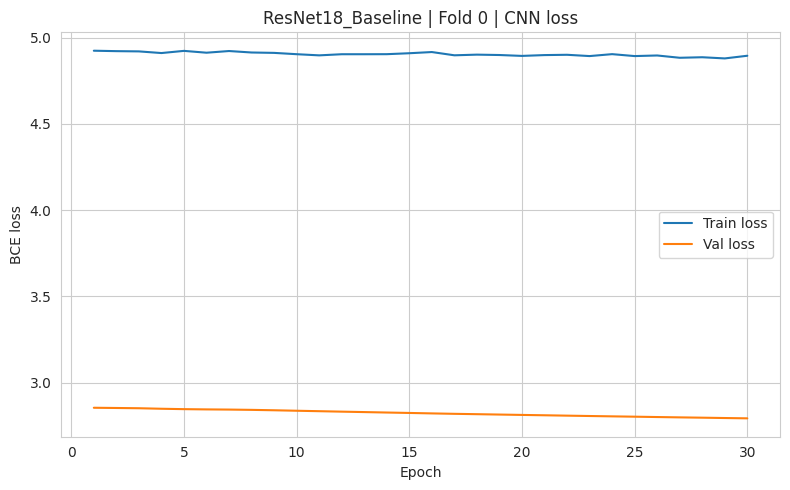

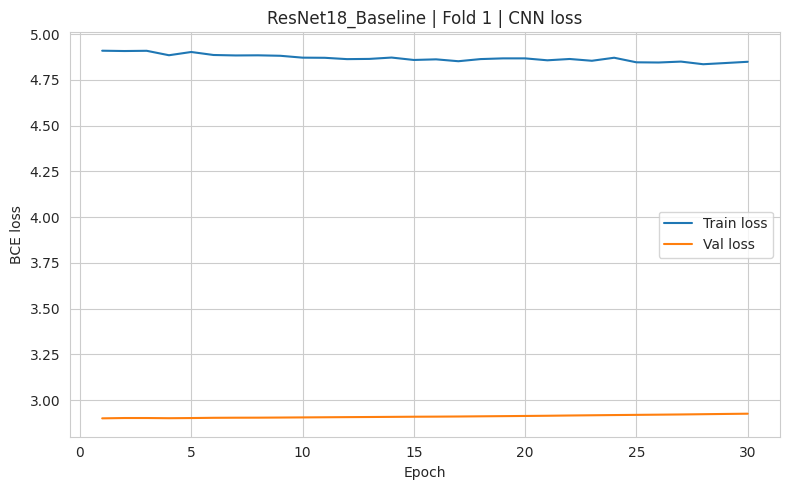

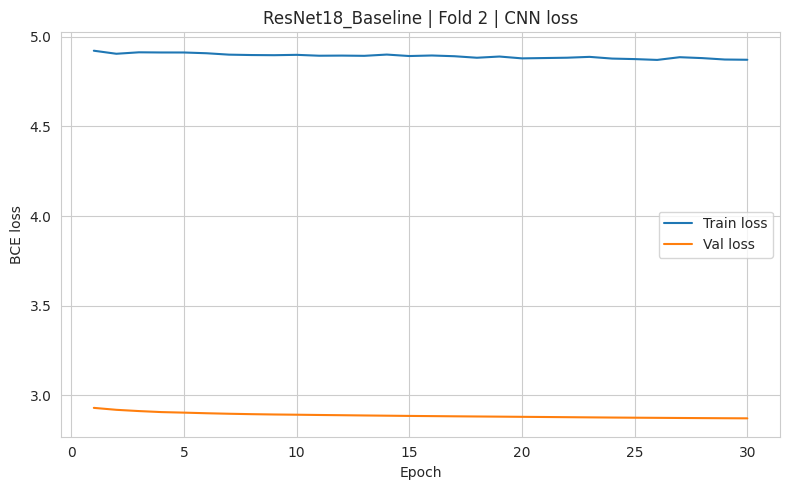

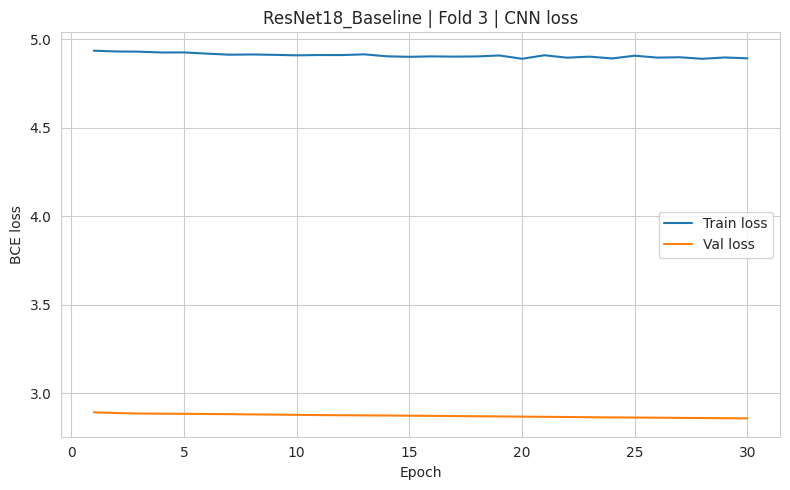

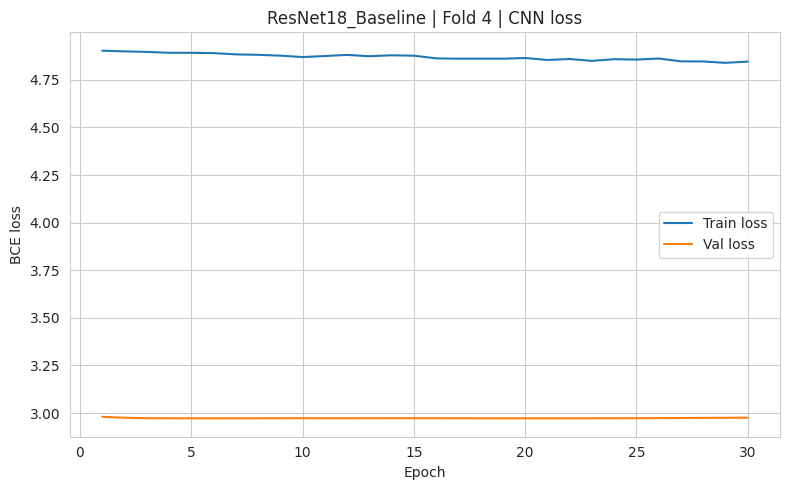

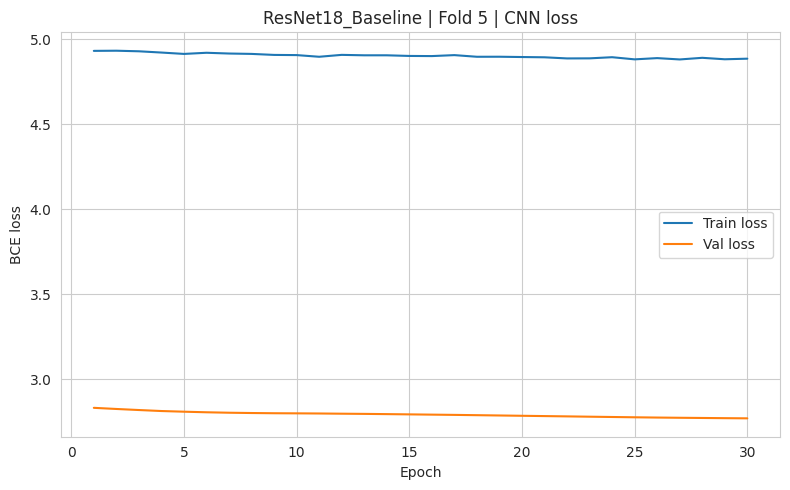

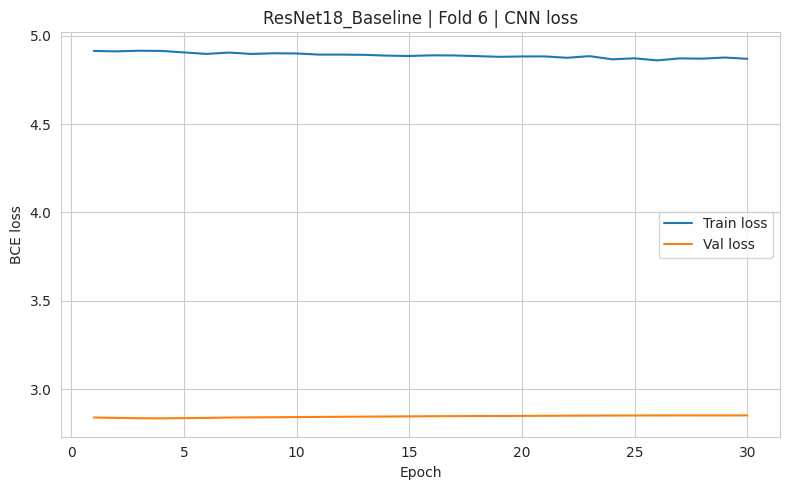

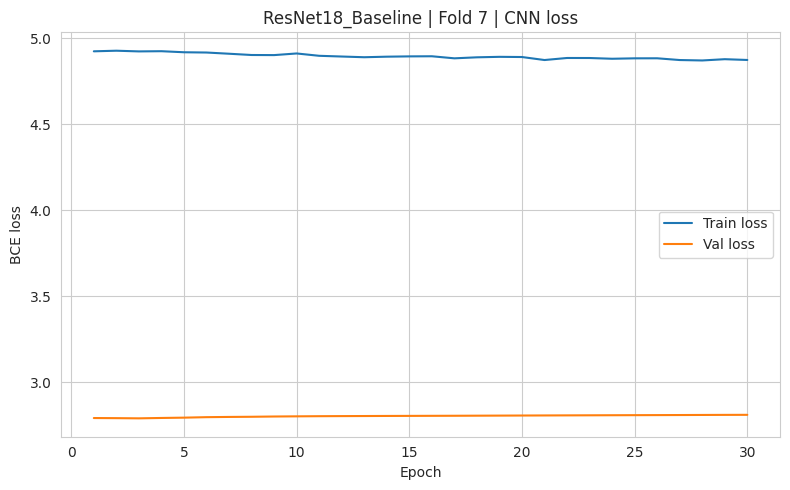

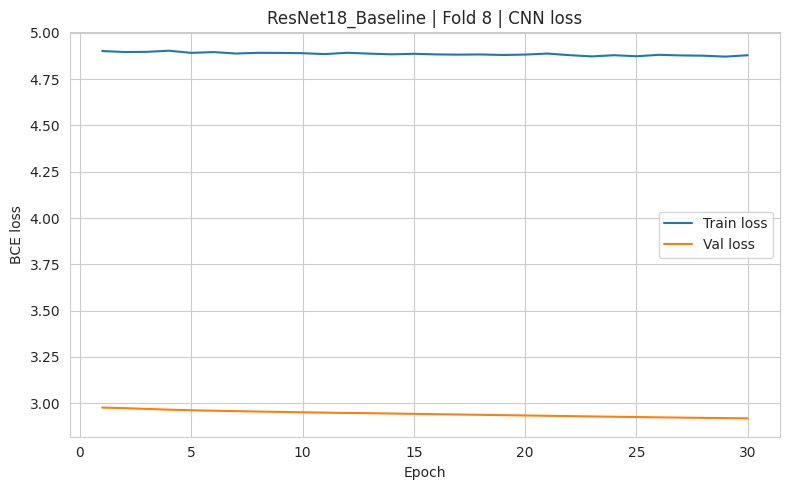

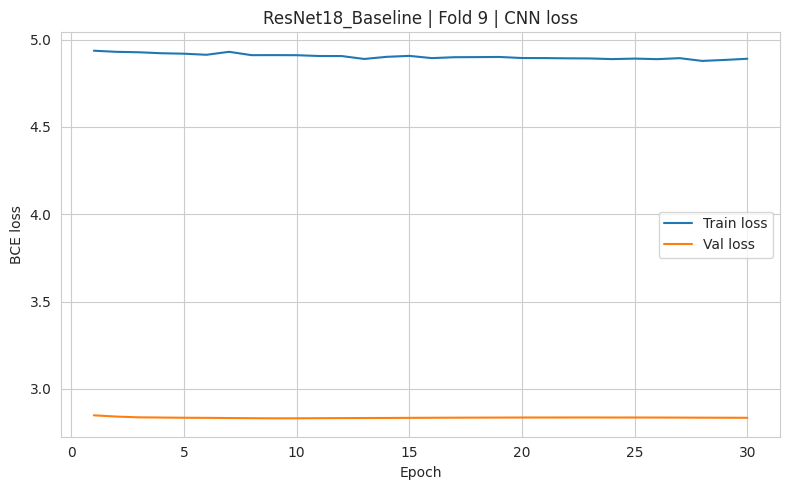

In [19]:
# %% ======================================================
# 13. Fold-wise CNN loss plots
# ==========================================================
if len(surv_history_df) == 0:
    print("cnn_history_df is empty.")
else:
    n_folds = surv_history_df["fold"].nunique()
    print("Number of folds in history:", n_folds)

    for fold in sorted(surv_history_df["fold"].unique()):
        sub = surv_history_df[surv_history_df["fold"] == fold].copy().sort_values("epoch")

        plt.figure(figsize=(8, 5))
        plt.plot(sub["epoch"], sub["train_loss"], label="Train loss")
        plt.plot(sub["epoch"], sub["val_loss"], label="Val loss")
        plt.title(f"{RUN_NAME} | Fold {fold} | CNN loss")
        plt.xlabel("Epoch")
        plt.ylabel("BCE loss")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
# %% ======================================================
# 14. Best CNN validation loss per fold
# ==========================================================
if len(surv_history_df) == 0:
    print("cnn_history_df is empty.")
else:
    best_cnn_loss_df = (
        surv_history_df.sort_values(["fold", "val_loss", "epoch"])
        .groupby("fold", as_index=False)
        .first()[["fold", "epoch", "train_loss", "val_loss"]]
        .rename(columns={
            "epoch": "best_epoch",
            "train_loss": "train_loss_at_best_val",
            "val_loss": "best_val_loss",
        })
    )

    print("Best CNN validation loss per fold:")
    display(best_cnn_loss_df)

Best CNN validation loss per fold:


,fold,best_epoch,train_loss_at_best_val,best_val_loss
0,0,30,4.895714,2.792910
1,1,1,4.909075,2.900519
2,2,30,4.871942,2.872050
3,3,30,4.893242,2.859370
4,4,6,4.890045,2.972366
5,5,30,4.884548,2.769548
6,6,4,4.913469,2.835476
7,7,3,4.924238,2.790602
8,8,30,4.878730,2.918476
9,9,9,4.911353,2.832017


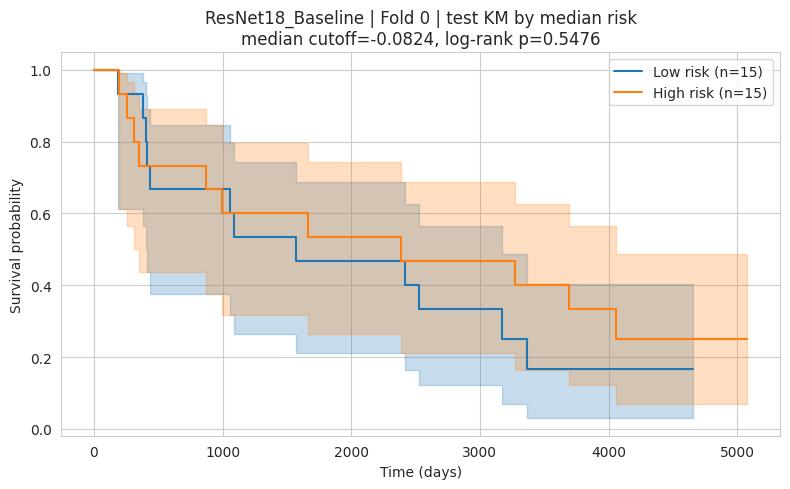

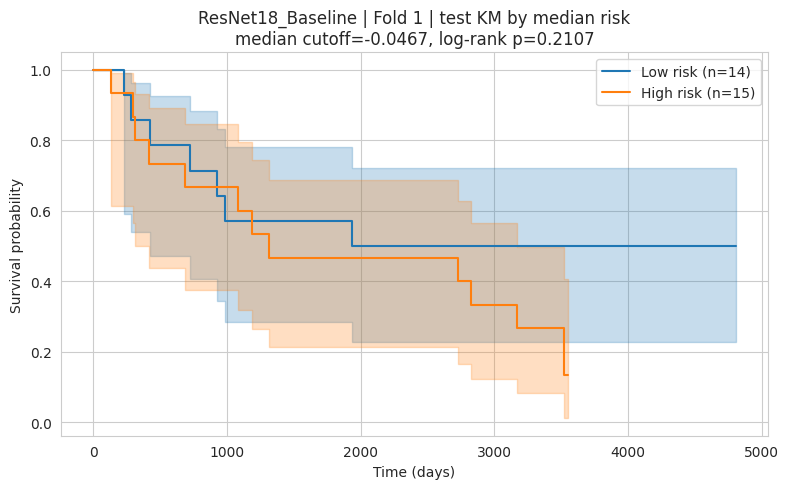

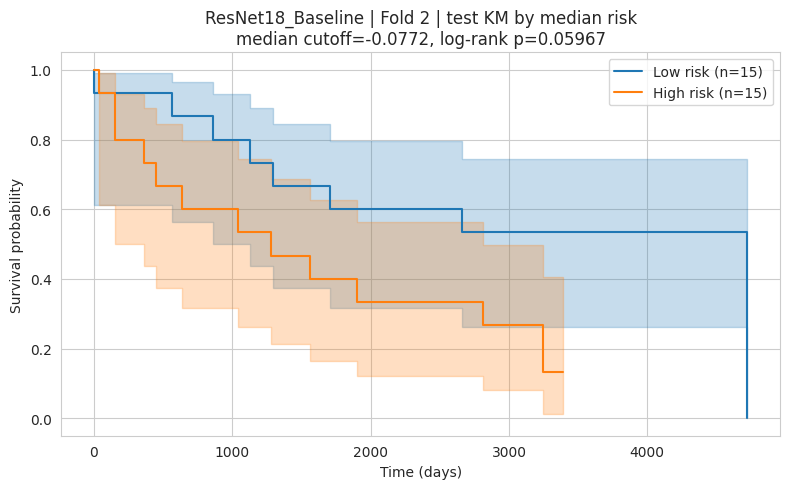

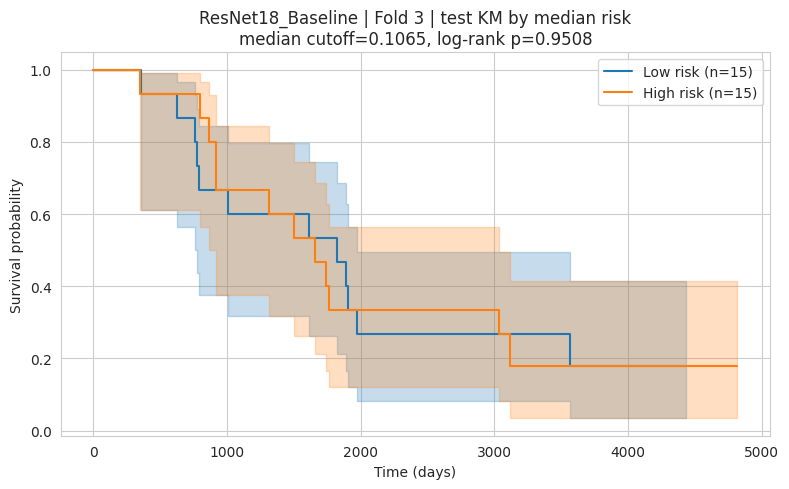

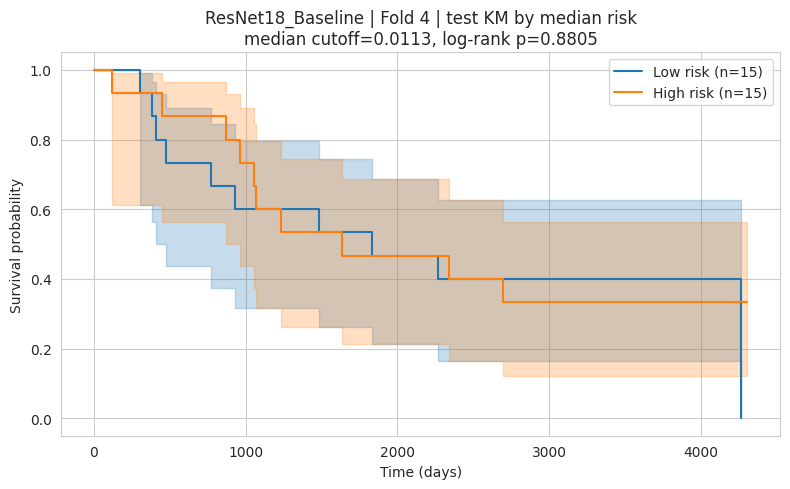

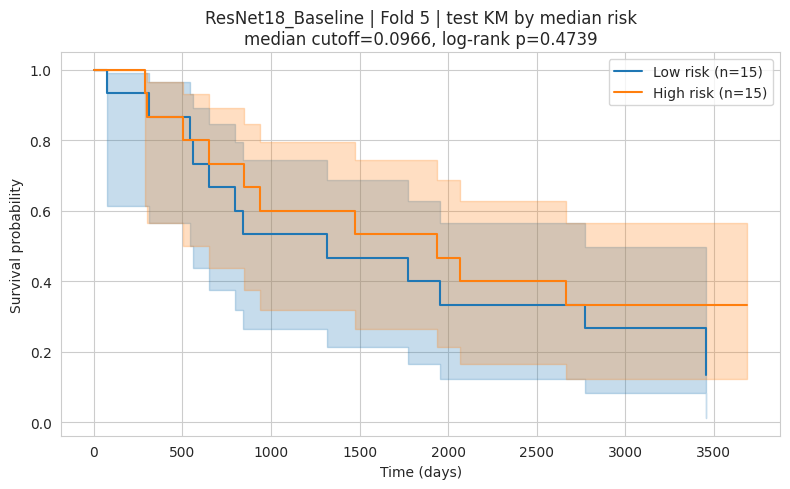

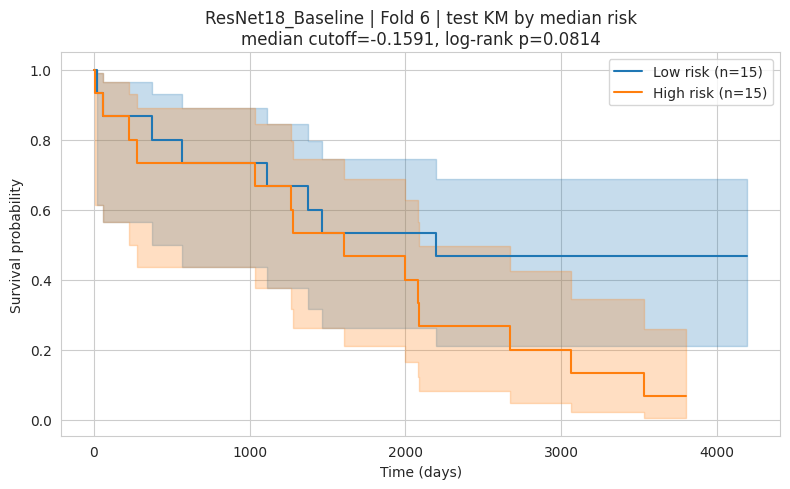

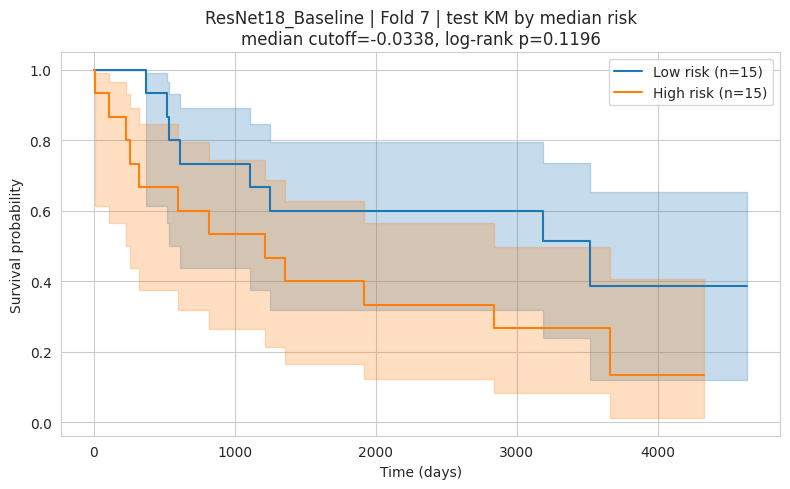

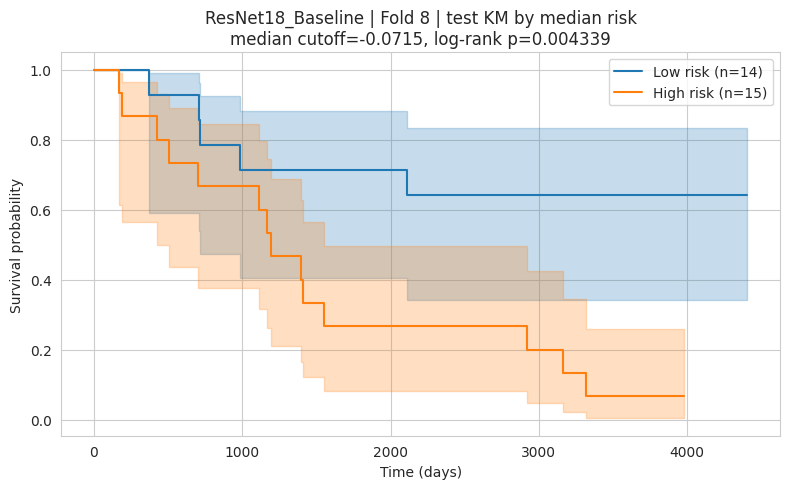

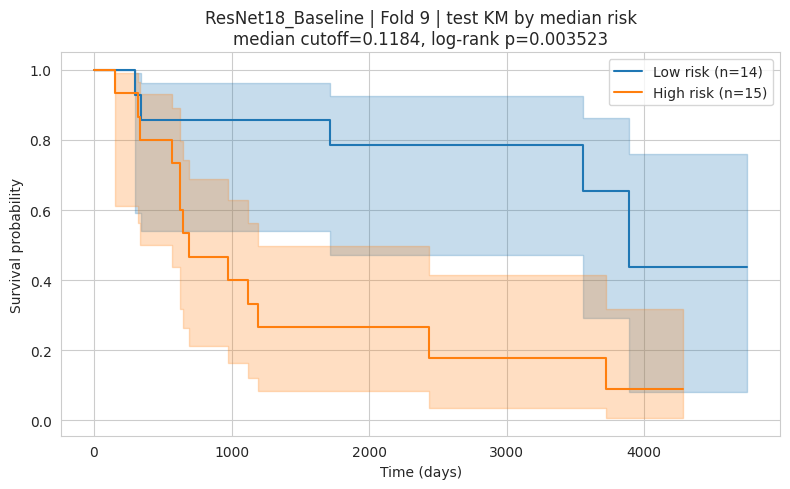

Fold-wise KM summary (test split):


,fold,split,n_patients,n_low,n_high,median_risk_cutoff,logrank_p
0,0,test,30,15,15,-0.082412,0.547551
1,1,test,29,14,15,-0.046701,0.210716
2,2,test,30,15,15,-0.077249,0.059668
3,3,test,30,15,15,0.106497,0.950778
4,4,test,30,15,15,0.011308,0.880454
5,5,test,30,15,15,0.096604,0.473867
6,6,test,30,15,15,-0.159130,0.081396
7,7,test,30,15,15,-0.033843,0.119551
8,8,test,29,14,15,-0.071517,0.004339
9,9,test,29,14,15,0.118432,0.003523


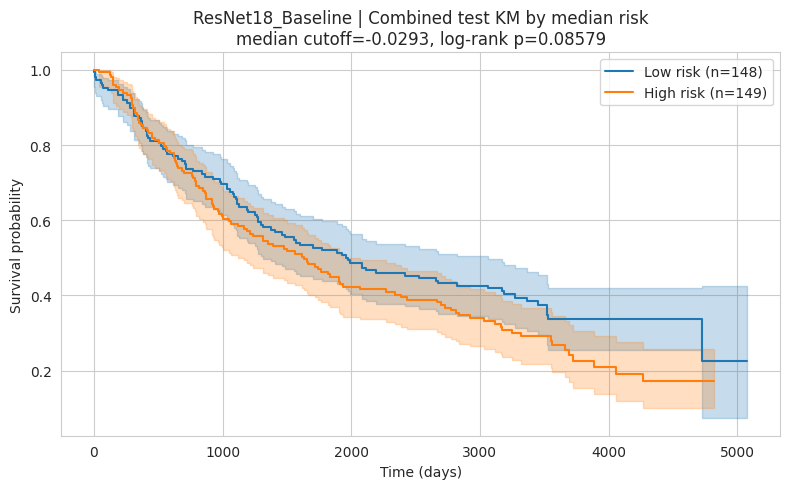

Combined KM summary (test split):


,split,n_patients,n_low,n_high,median_risk_cutoff,logrank_p
0,test,297,148,149,-0.029277,0.085786


In [21]:
# %% ======================================================
# 15. KM curves by median risk score
# ==========================================================
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

def plot_km_by_median_risk_foldwise(fold_data, split="test", title_prefix=RUN_NAME):
    """
    For each fold:
      - use patient-level risk scores already stored in fold_data[fold][split]["df"]
      - split patients into low/high risk by the median risk within that fold/split
      - plot Kaplan-Meier curves
      - compute log-rank p-value
    """
    km_rows = []

    folds_available = sorted(fold_data.keys())
    for fold in folds_available:
        if split not in fold_data[fold]:
            continue

        df_eval = fold_data[fold][split]["df"].copy()

        required_cols = ["patient_id", "time", "event", "risk_score"]
        missing_cols = [c for c in required_cols if c not in df_eval.columns]
        if len(missing_cols) > 0:
            print(f"Fold {fold} | split={split}: missing columns {missing_cols}, skipping")
            continue

        sub = df_eval.dropna(subset=["time", "event", "risk_score"]).copy()

        if len(sub) < 2:
            print(f"Fold {fold} | split={split}: not enough patients for KM plot")
            continue

        median_risk = sub["risk_score"].median()
        sub["risk_group"] = np.where(sub["risk_score"] >= median_risk, "High risk", "Low risk")

        high = sub[sub["risk_group"] == "High risk"].copy()
        low = sub[sub["risk_group"] == "Low risk"].copy()

        if len(high) == 0 or len(low) == 0:
            print(f"Fold {fold} | split={split}: one group is empty, skipping")
            continue

        kmf_high = KaplanMeierFitter()
        kmf_low = KaplanMeierFitter()

        plt.figure(figsize=(8, 5))

        kmf_low.fit(
            durations=low["time"].values,
            event_observed=low["event"].values,
            label=f"Low risk (n={len(low)})"
        )
        kmf_low.plot(ci_show=True)

        kmf_high.fit(
            durations=high["time"].values,
            event_observed=high["event"].values,
            label=f"High risk (n={len(high)})"
        )
        kmf_high.plot(ci_show=True)

        lr = logrank_test(
            low["time"].values,
            high["time"].values,
            event_observed_A=low["event"].values,
            event_observed_B=high["event"].values
        )

        plt.title(
            f"{title_prefix} | Fold {fold} | {split} KM by median risk\n"
            f"median cutoff={median_risk:.4f}, log-rank p={lr.p_value:.4g}"
        )
        plt.xlabel("Time (days)")
        plt.ylabel("Survival probability")
        plt.tight_layout()
        plt.show()

        km_rows.append({
            "fold": fold,
            "split": split,
            "n_patients": len(sub),
            "n_low": len(low),
            "n_high": len(high),
            "median_risk_cutoff": median_risk,
            "logrank_p": lr.p_value,
        })

    return pd.DataFrame(km_rows)


def plot_km_by_median_risk_combined(fold_data, split="test", title_prefix=RUN_NAME):
    """
    Combine all folds for the chosen split into one KM plot.

    If a patient appears more than once across folds, their risk is averaged and
    time/event are taken from the first occurrence.
    """
    all_rows = []

    for fold in sorted(fold_data.keys()):
        if split not in fold_data[fold]:
            continue

        df_eval = fold_data[fold][split]["df"].copy()

        required_cols = ["patient_id", "time", "event", "risk_score"]
        missing_cols = [c for c in required_cols if c not in df_eval.columns]
        if len(missing_cols) > 0:
            print(f"Fold {fold} | split={split}: missing columns {missing_cols}, skipping")
            continue

        sub = df_eval[required_cols].dropna().copy()
        sub["fold"] = fold
        all_rows.append(sub)

    if len(all_rows) == 0:
        print(f"No data found for combined KM plot on split={split}")
        return pd.DataFrame()

    combined = pd.concat(all_rows, axis=0, ignore_index=True)

    # In proper CV test splits, each patient usually appears only once.
    # This safeguard handles duplicates if they exist.
    combined = (
        combined.groupby("patient_id", as_index=False)
        .agg(
            time=("time", "first"),
            event=("event", "first"),
            risk_score=("risk_score", "mean"),
        )
    )

    if len(combined) < 2:
        print(f"Combined split={split}: not enough patients for KM plot")
        return pd.DataFrame()

    median_risk = combined["risk_score"].median()
    combined["risk_group"] = np.where(combined["risk_score"] >= median_risk, "High risk", "Low risk")

    high = combined[combined["risk_group"] == "High risk"].copy()
    low = combined[combined["risk_group"] == "Low risk"].copy()

    if len(high) == 0 or len(low) == 0:
        print(f"Combined split={split}: one group is empty, skipping")
        return pd.DataFrame()

    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()

    plt.figure(figsize=(8, 5))

    kmf_low.fit(
        durations=low["time"].values,
        event_observed=low["event"].values,
        label=f"Low risk (n={len(low)})"
    )
    kmf_low.plot(ci_show=True)

    kmf_high.fit(
        durations=high["time"].values,
        event_observed=high["event"].values,
        label=f"High risk (n={len(high)})"
    )
    kmf_high.plot(ci_show=True)

    lr = logrank_test(
        low["time"].values,
        high["time"].values,
        event_observed_A=low["event"].values,
        event_observed_B=high["event"].values
    )

    plt.title(
        f"{title_prefix} | Combined {split} KM by median risk\n"
        f"median cutoff={median_risk:.4f}, log-rank p={lr.p_value:.4g}"
    )
    plt.xlabel("Time (days)")
    plt.ylabel("Survival probability")
    plt.tight_layout()
    plt.show()

    combined_summary_df = pd.DataFrame([{
        "split": split,
        "n_patients": len(combined),
        "n_low": len(low),
        "n_high": len(high),
        "median_risk_cutoff": median_risk,
        "logrank_p": lr.p_value,
    }])

    return combined_summary_df


# ----------------------------------------------------------
# Run fold-wise KM plots
# ----------------------------------------------------------
km_test_foldwise_df = plot_km_by_median_risk_foldwise(
    fold_data=fold_data,
    split="test",
    title_prefix=RUN_NAME
)

print("Fold-wise KM summary (test split):")
display(km_test_foldwise_df)


# ----------------------------------------------------------
# Run one combined KM plot across all folds
# ----------------------------------------------------------
km_test_combined_df = plot_km_by_median_risk_combined(
    fold_data=fold_data,
    split="test",
    title_prefix=RUN_NAME
)

print("Combined KM summary (test split):")
display(km_test_combined_df)